<a href="https://colab.research.google.com/github/J4SIB/ai-course-gp/blob/main/lesson19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 9.6 MB/s eta 0:00:00


In [ ]:
import skfuzzy as fuzz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
import math
#from sklearn.datasets import load_iris

In [ ]:
#iris = load_iris()
#df = pd.DataFrame(iris.data, columns=iris.feature_names)
#df['species'] = iris.target

#print(df.head(10))

In [ ]:
df = sns.load_dataset("iris")
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
#X = df[['petal length (cm)', 'petal width (cm)']]
#y = df['species']


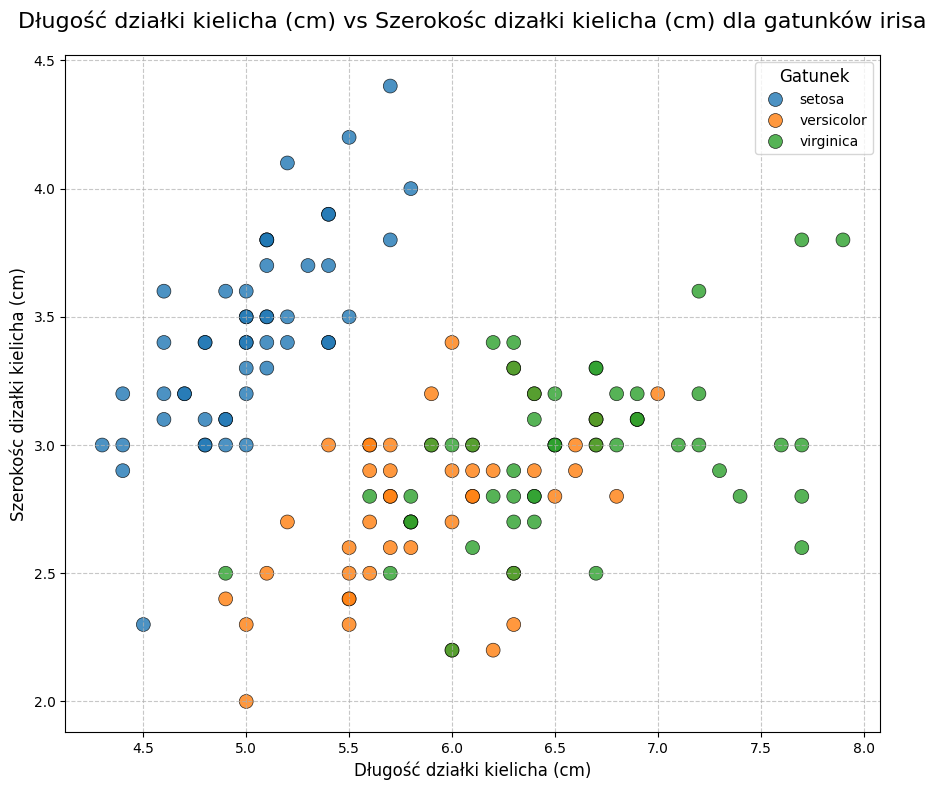

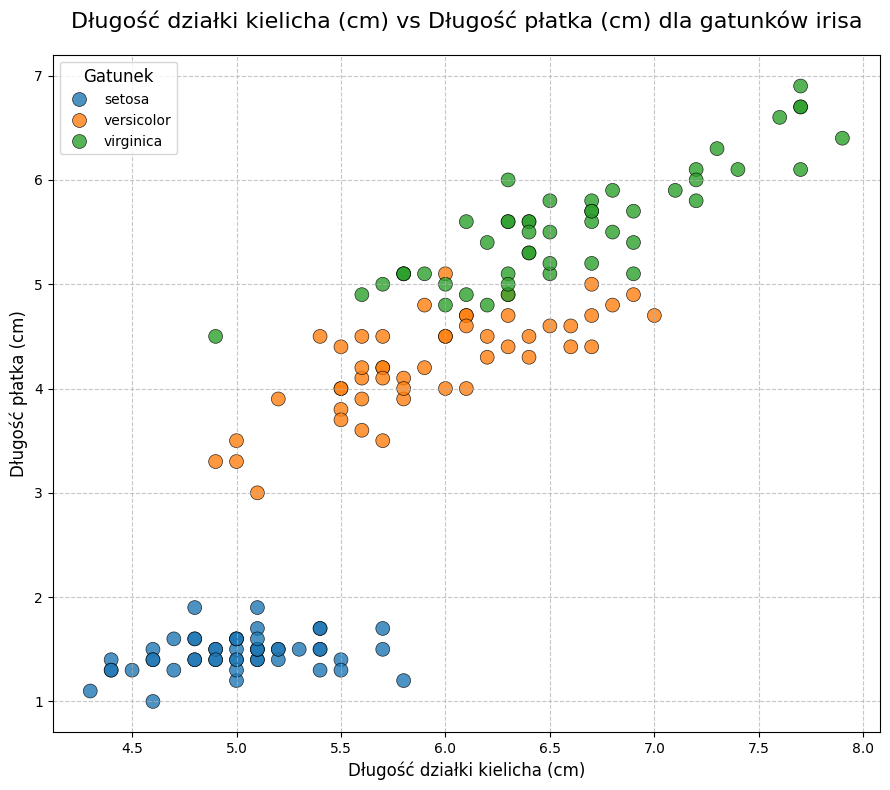

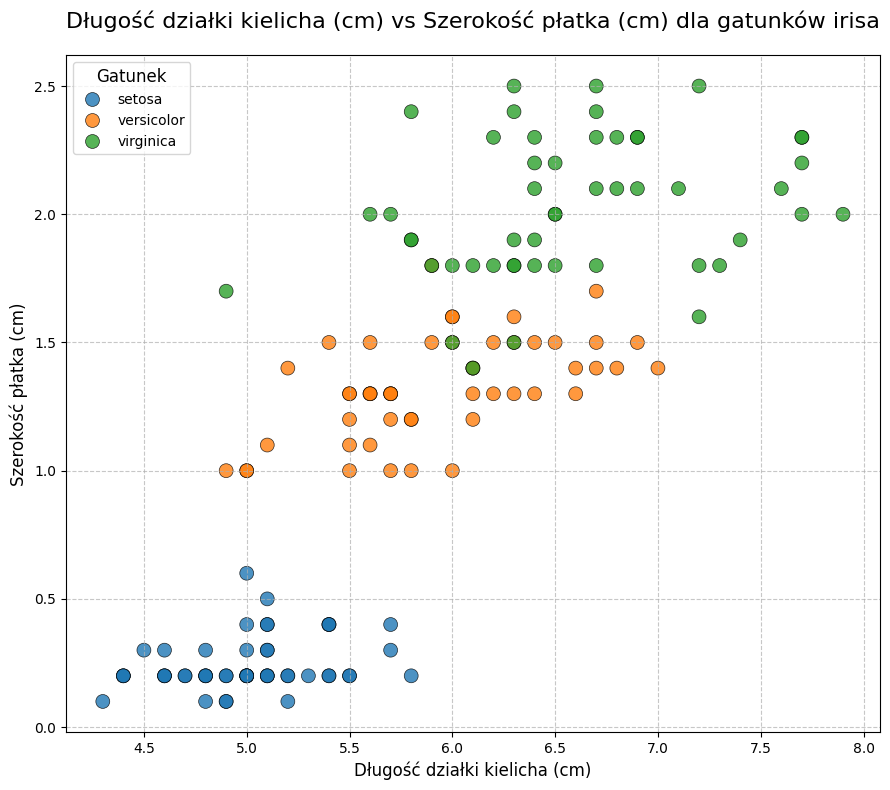

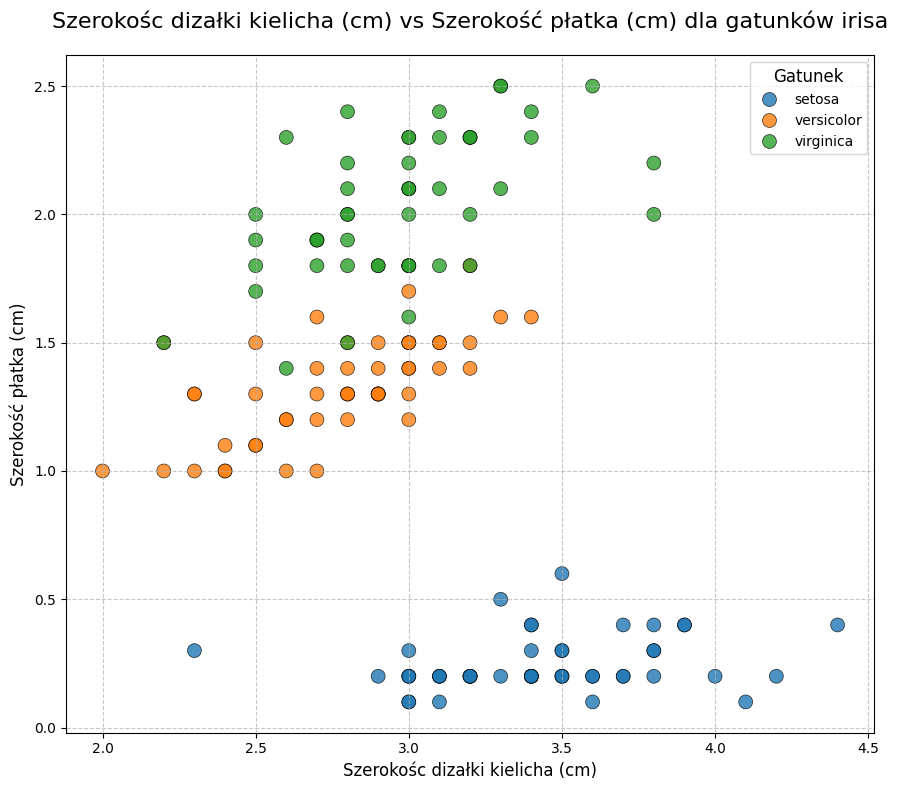

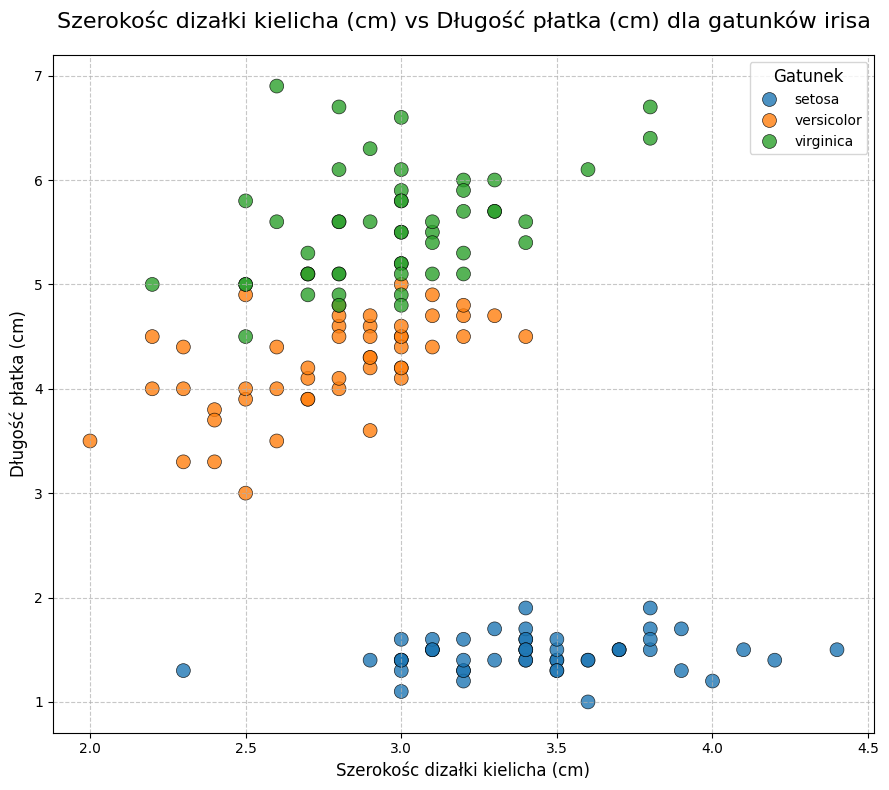

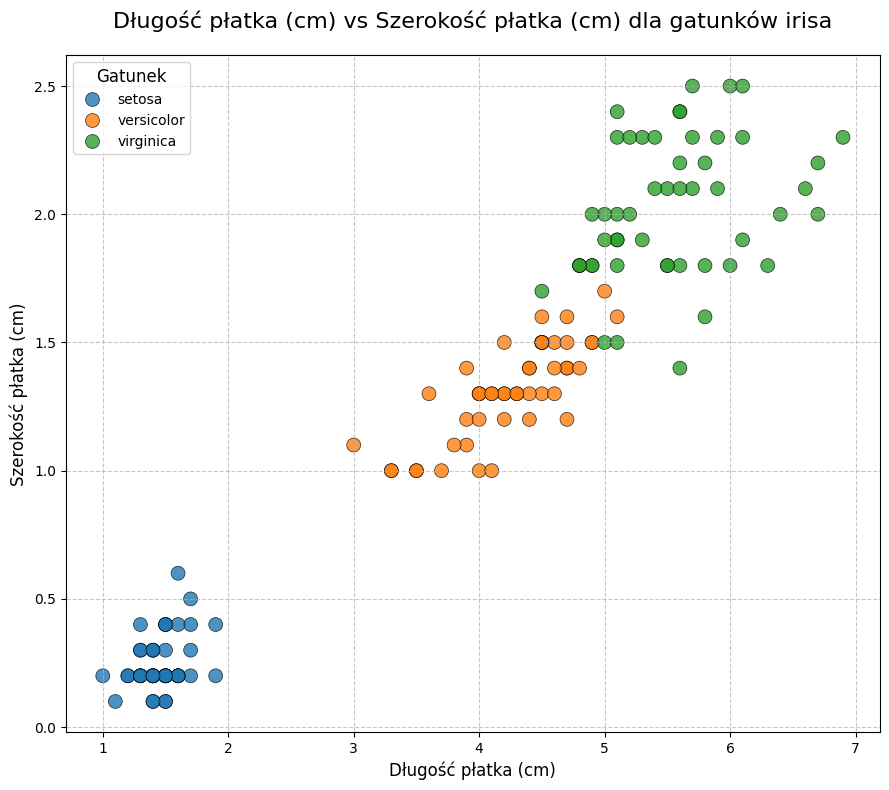

In [ ]:
feature_pairs = [
    ('sepal_length','sepal_width'),
     ('sepal_length','petal_length'),
     ('sepal_length','petal_width'),
     ('sepal_width','petal_width'),
     ('sepal_width','petal_length'),
     ('petal_length','petal_width')
]

feature_names_pl = {
    'sepal_length': 'Długość działki kielicha (cm)',
    'sepal_width': 'Szerokośc dizałki kielicha (cm)',
    'petal_length': 'Długość płatka (cm)',
    'petal_width' : 'Szerokość płatka (cm)',
}

for x_feature, y_feature in feature_pairs:
  plt.figure(figsize=(9,8))
  scatter = sns.scatterplot(
      data=df,
      x = x_feature,
      y = y_feature,
      hue='species',
      s = 100,
      alpha = 0.8,
      edgecolor = 'k',
      linewidth = 0.5,
  )
  x_name_pl = feature_names_pl[x_feature]
  y_name_pl = feature_names_pl[y_feature]
  plt.title(f'{x_name_pl} vs {y_name_pl} dla gatunków irisa', fontsize = 16, pad = 20)
  plt.xlabel(x_name_pl, fontsize = 12)
  plt.ylabel(y_name_pl, fontsize = 12)
  plt.legend(title = 'Gatunek', fontsize = 10,title_fontsize = 12)
  plt.grid(True, linestyle='--',alpha = 0.7)
  plt.tight_layout()
  plt.show()


In [33]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df_train, df_test = train_test_split(df, test_size=0.30, random_state=42)
features = [
    'petal length (cm)',
    'petal width (cm)',
]
species = iris.target_names
results = []
for feature in features:
  for specie in species:
    data = df_test[df_test['species'] == specie][feature]
    results.append({
        "Feature": feature,
        'Species': specie,
        "Minimum": 0.9 * data.min(),
        "Maximum": 1.1 * data.max(),
        "Mean": data.mean()
    })

summary_df = pd.DataFrame(results)
summary_df


,Feature,Species,Minimum,Maximum,Mean
0,petal length (cm),setosa,0.90,1.87,1.457895
1,petal length (cm),versicolor,3.24,5.28,4.400000
2,petal length (cm),virginica,4.41,7.59,5.569231
3,petal width (cm),setosa,0.09,0.44,0.242105
4,petal width (cm),versicolor,0.99,1.76,1.392308
5,petal width (cm),virginica,1.62,2.53,2.084615


In [34]:
#Klasyfikacja na podstawie długości i szerokości płatka.

# Import bibliotek
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.datasets import load_iris

# Załaduj dane Iris (wszystkie 4 cechy)
iris = load_iris()
X = iris.data[:, :]
y = iris.target

# Użycie całych danych do testowania
X_test = X
y_test = y

# Definicja zmiennych wejściowych
sepal_length = ctrl.Antecedent(np.linspace(4, 8, 1000), 'sepal_length')
sepal_width = ctrl.Antecedent(np.linspace(2, 5, 1000), 'sepal_width')
petal_length = ctrl.Antecedent(np.linspace(1, 7, 1000), 'petal_length')
petal_width = ctrl.Antecedent(np.linspace(0, 2.5, 1000), 'petal_width')

# Definicja zmiennej wyjściowej
species = ctrl.Consequent(np.linspace(0, 2, 1000), 'species')

# Funkcje przynależności
petal_length['setosa'] = fuzz.trimf(petal_length.universe, [0.8, 1.45,  2.44])
petal_length['versicolor'] = fuzz.trimf(petal_length.universe, [2.44 , 4.40, 5.76])
petal_length['virginica'] = fuzz.trimf(petal_length.universe, [ 3.92, 5.57, 8.28])

petal_width['setosa'] = fuzz.trimf(petal_width.universe, [0.08, 0.24, 0.66])
petal_width['versicolor'] = fuzz.trimf(petal_width.universe, [0.66, 1.39, 1.92])
petal_width['virginica'] = fuzz.trimf(petal_width.universe, [1.44, 2.08, 2.76])

# Funkcje przynależności dla wyjścia
species['setosa'] = fuzz.trimf(species.universe, [0, 0, 0.5])
species['versicolor'] = fuzz.trimf(species.universe, [0.5, 1, 1.5])
species['virginica'] = fuzz.trimf(species.universe, [1.5, 2, 2])


# Definicja reguł
rule1 = ctrl.Rule(petal_length['setosa'] & petal_width['setosa'], species['setosa'])
rule2 = ctrl.Rule(petal_length['versicolor'] & petal_width['versicolor'], species['versicolor'])
rule3 = ctrl.Rule(petal_length['virginica'] & petal_width['virginica'], species['virginica'])


# Tworzenie systemu sterowania
species_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])

# Klasyfikacja testowa
y_pred = []
for sl, sw, pl, pw in X_test:
    species_sim = ctrl.ControlSystemSimulation(species_ctrl)
    species_sim.input['petal_length'] = pl
    species_sim.input['petal_width'] = pw

    species_sim.compute()
    fuzzy_result = species_sim.output['species']

    if fuzzy_result < 0.5:
        y_pred.append(0)
    elif fuzzy_result < 1.5:
        y_pred.append(1)
    else:
        y_pred.append(2)

# Ewaluacja modelu
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.82      1.00      0.90        50
   virginica       1.00      0.78      0.88        50

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150

